# # 🏠 House Price Prediction – Model Training

This notebook focuses on:

- Loading cleaned dataset
- Splitting data into training & testing sets
- Training multiple regression models
- Comparing performance
- Selecting best model
- Saving final model

Target Variable: SalePrice (Log Transformed)

Goal: Achieve 0.88 – 0.93 R² score

In [19]:
import sys
!{sys.executable} -m pip install xgboost

In [20]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import joblib

In [21]:
df = pd.read_csv("../data/processed/cleaned_train.csv")
df.shape

(1456, 232)

In [22]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (1456, 231)
Target shape: (1456,)


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (1164, 231)
Testing size: (292, 231)


In [24]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression R²:", r2_score(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

Linear Regression R²: 0.8991985261928743
RMSE: 0.1261761898529608


In [25]:
rf = RandomForestRegressor(
    n_estimators=400,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest R²:", r2_score(y_test, y_pred_rf))

Random Forest R²: 0.8598706938896105


In [26]:
xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost R²:", r2_score(y_test, y_pred_xgb))

XGBoost R²: 0.8983216151262385


In [27]:
cv_score = cross_val_score(xgb, X, y, cv=5, scoring="r2")

print("Cross Validation R²:", cv_score.mean())

Cross Validation R²: 0.9089973182784117


In [28]:
xgb = XGBRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    max_depth=3,
    min_child_weight=3,
    subsample=0.7,
    colsample_bytree=0.7,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("Improved XGBoost R²:", r2_score(y_test, y_pred_xgb))

Improved XGBoost R²: 0.9001325978278376


In [31]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2 = r2_score(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae = mean_absolute_error(y_test, y_pred_xgb)

print("R²:", r2)
print("RMSE:", rmse)
print("MAE:", mae)


R²: 0.9001325978278376
RMSE: 0.1255902266809519
MAE: 0.08789770747362737


In [32]:
from sklearn.model_selection import cross_val_score

cv = cross_val_score(xgb, X, y, cv=5, scoring="r2")
print("CV Mean:", cv.mean())
print("CV Std:", cv.std())

CV Mean: 0.9081614164194377
CV Std: 0.005691510217320194


In [35]:
from lightgbm import LGBMRegressor

lgb = LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    max_depth=-1,
    num_leaves=31,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42
)

lgb.fit(X_train, y_train)

y_pred_lgb = lgb.predict(X_test)

print("LightGBM R²:", r2_score(y_test, y_pred_lgb))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002369 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3404
[LightGBM] [Info] Number of data points in the train set: 1164, number of used features: 151
[LightGBM] [Info] Start training from score 12.028422
LightGBM R²: 0.892583999417898


In [36]:
y_pred_rf = rf.predict(X_test)
y_pred_xgb = xgb.predict(X_test)
y_pred_lgb = lgb.predict(X_test)

# Weighted average
ensemble_pred = (
    0.2 * y_pred_rf +
    0.4 * y_pred_xgb +
    0.4 * y_pred_lgb
)

print("Ensemble R²:", r2_score(y_test, ensemble_pred))

Ensemble R²: 0.8947969552034307


In [37]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

ensemble_scores = []

for train_idx, val_idx in kf.split(X):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    rf.fit(X_tr, y_tr)
    xgb.fit(X_tr, y_tr)
    lgb.fit(X_tr, y_tr)
    
    pred = (
        0.2 * rf.predict(X_val) +
        0.4 * xgb.predict(X_val) +
        0.4 * lgb.predict(X_val)
    )
    
    ensemble_scores.append(r2_score(y_val, pred))

print("Ensemble CV Mean:", np.mean(ensemble_scores))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002057 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3404
[LightGBM] [Info] Number of data points in the train set: 1164, number of used features: 151
[LightGBM] [Info] Start training from score 12.028422
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003695 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3407
[LightGBM] [Info] Number of data points in the train set: 1165, number of used features: 151
[LightGBM] [Info] Start training from score 12.026970
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of 

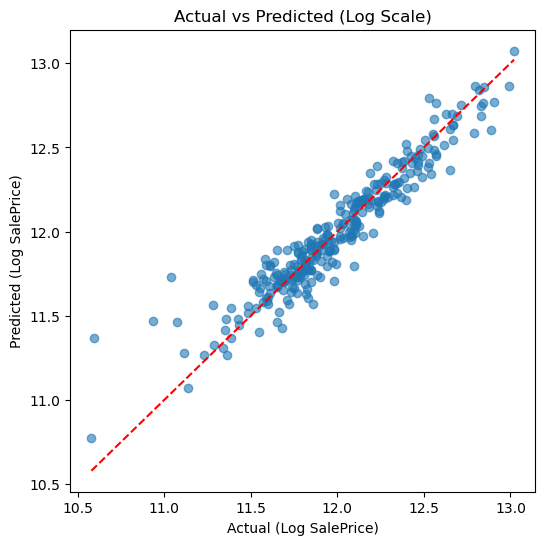

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_xgb, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Actual (Log SalePrice)")
plt.ylabel("Predicted (Log SalePrice)")
plt.title("Actual vs Predicted (Log Scale)")
plt.show()

In [39]:
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_xgb)

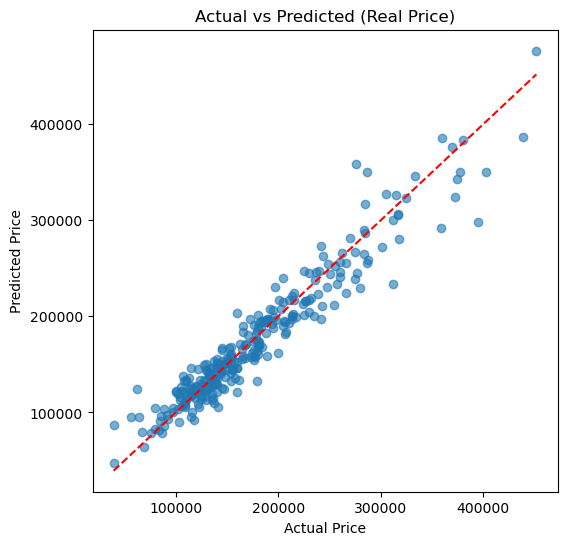

In [40]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_real, y_pred_real, alpha=0.6)
plt.plot([y_test_real.min(), y_test_real.max()],
         [y_test_real.min(), y_test_real.max()],
         'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Real Price)")
plt.show()

In [41]:
comparison_df = pd.DataFrame({
    "Actual Price": y_test_real,
    "Predicted Price": y_pred_real,
})

comparison_df["Error"] = comparison_df["Actual Price"] - comparison_df["Predicted Price"]
comparison_df["Absolute Error"] = comparison_df["Error"].abs()

comparison_df.head(10)

,Actual Price,Predicted Price,Error,Absolute Error
497,184000.0,168207.250000,15792.750000,15792.750000
1261,181000.0,168772.046875,12227.953125,12227.953125
411,145000.0,142889.640625,2110.359375,2110.359375
1046,115000.0,146237.890625,-31237.890625,31237.890625
1033,84000.0,81310.109375,2689.890625,2689.890625
613,75500.0,78249.437500,-2749.437500,2749.437500
218,311500.0,233920.859375,77579.140625,77579.140625
1182,104900.0,126271.039062,-21371.039062,21371.039062
1191,158000.0,136124.546875,21875.453125,21875.453125
885,135500.0,131619.718750,3880.281250,3880.281250


In [42]:
print("Mean Absolute Error (Real Price):",
      comparison_df["Absolute Error"].mean())

Mean Absolute Error (Real Price): 14606.63206335618


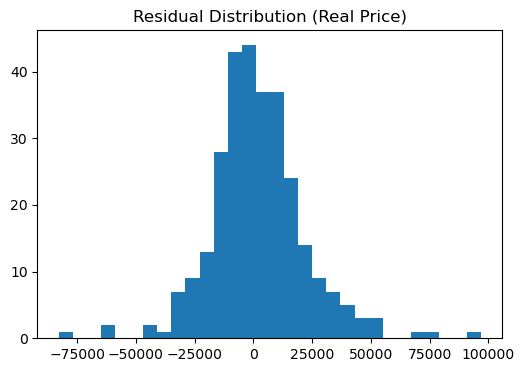

In [43]:
residuals = y_test_real - y_pred_real

plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30)
plt.title("Residual Distribution (Real Price)")
plt.show()

In [45]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=4000,
    learning_rate=0.015,
    max_depth=4,
    min_child_weight=2,
    subsample=0.75,
    colsample_bytree=0.75,
    gamma=0.05,
    reg_alpha=0.05,
    reg_lambda=1.2,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.75, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.05, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.015, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=2, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=4000,
             n_jobs=-1, num_parallel_tree=None, ...)

In [46]:
import joblib
joblib.dump(xgb_model, "best_house_price_model.pkl")

['best_house_price_model.pkl']

In [47]:
joblib.dump(X.columns, "model_features.pkl")
print("Feature list saved successfully!")

Feature list saved successfully!
